## 1.2 Classification.    
Classification is a type of supervised machine learning where the goal is to predict a categorical label(class) for a given input based on previously labelled trained data.     
__Types of Classification ML tasks__      
1. Binary Classification: Predicts one of two possible classes. e.g email filtering(spam or not spam), loan defaulted or paid.     
2. Multi-class classification: The model predicts one class out of three or more categories. Train a model that can predict a car model.     
3. Multi-Label Classification: An observation can belong to multiple classes simultaneously. e.g A movie can fall under more than 1 genres e.g Romance + Action + Comedy.     


_Popular classification algorithms_      
- Logistic Regression.    
- K-Nearest Neighbors.    
- Decision Trees.   
- Random Forest
- Gradient Boosting.   
- Naive Bayes.  
- Support Vector Machine(SVM)
- Neural Networks.    

### Evaluation Metrics in Classification.   
#### a). Confusion Matrix.   
It is a simple table that compares what the model predicted against what actually happened.   
Assume tyou're predicting either a Positive or a Negative.    

|               |Predicted Positive|Predicted Negative|
|---------------|------------------|------------------|
|Actual Positive|True Positve(TP)  |False Negative(FN)|
|Actual Negative|False Positive(FP)|True Negative(TN) |     

The four possible outcomes:    
- True Positive(TP): The model predicted positive and it was actually positive.    
- True Negative(TN): The model predicted negative and it was actually negative.     
- False Positive(FP): The model predicted positive but it was actually negative(A false alarm)
- False Negative(FN): The model predicted negative but it was actually positive(A miss).    

#### b). Accuracy.    
Accuracy tells us the percentage of predictions the model got right, out of all predictions made.     

_Formula_  
$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$    or $Accuracy = \frac{Total correct predictions}{Totalpredictions}$     

Accuracy can be misleading when the classes are imbalanced. For example, if 95% of emails are not spam, a model that always predicts not spam will have 95% accuracy without being useful at all.  100 total mails, 95 not spam, 5 spammy.     

|           |Spam  |Not spam|
|-----------|------|--------|
|Spam       |0     |5       |
|Not Spam   |0     |95      |     

$Accuracy = \frac{0 + 95}{0 + 0 + 95 + 5}$    

_Use when_ Your classes are roughly balanced and every type of mistake costs about the same.    
_Avoid it when_ Your classes are imbalanced.  


In [1]:
accuracy = 95/100
print(accuracy)

0.95


## 16th July 2026

#### c). Precision.      
Precision answers the question: of everything the model has labelled as positive, ho many were actually positive?      

_Formula_    
$Precision = \frac{TP}{TP + FP}$   

High precision means the model does not raise many false alarms. This matters when the cost of a false positive is high, for example flagging a genuine transaction as fraud.      

_Use it when_ Flase positives are costly or disruptive, such as marking a good transaction as Fraud or a real email as spam.     
_Avoid it when_ Missing a positive case is far more costly than a false alarm, since precision on its own ignores false negatives.     

#### d). Recall(Sensitivity).     
Recall answers the question: Of all the actual positives, how many did the model correctly find?      

_Formula_    
$Recall \frac{TP}{TP + FN}$      

High recall means the model rarely misses a true positive. This matters when missing a positive case is costly, for example failing to detect a disease.     

_Use it when_ Missing a positive case is dangerous or expensive, such as in medical screening or security threat detection.        
_Avoid it when_ Flase alarms are costly and need to stay low, since recall on its own ignores flase positives.    

#### e). F1-Score.   
Precision and recall often trade off against each other. The F1 Score combines both into a single number using their harmonic mean, so it is useful when you want one balanced measure.     

_Formula_      
$F1 = {2} * \frac{Precision*Recall}{Precision + Recall}$     

The F1-Score is especially helpful when the classes are imbalanced and accuracy alone is not trustworthy.       

_Use it when_ You need one single score that balances precision and recall, especially with imbalanced classes.     
_Avoid it when_ You care alot more about one of precision or recall specifically, since F1 hides that difference by averaging them.     

#### f). Macro F1 Score.    
The F1 Score above works for a single class, such as posive versus negative. When there are more than two classes for example classifying an image as a cat, dog, bird or rabbit, you need a way to combine the F1 Scores of every class into one number.  Macro-F1, it calculates the F1 Score separately for each class then takes plain average across all classes.     

_Formula_     
$Macro F1 = \frac{\text{F1 for class 1} + \text{F1 for class 2} +...\text{F1 for class n}}{n}$  

The word macro means every class counts equally, no matter how many examples it has.     
_Use when_ You have multiple classes and want every class including rare ones to matter equally.   
_Avoid it when_ Your classes are very imbalanced and the rare classes are not of priority.   

#### g). Weighted F1 Score.   
It calculates the F1 score of each class independently and then takes the average, with each class's F1 score weighted by its support(Number of actual true instances of that class).       
For example if you are predicting three classes(A, B and C) and class A makes up 80% of your data, the weighted F1 will heavily lean on how well your model classifies Class.    

_Formula_    
${Weighted\ F1}=\sum _{i=1}^{N}\left(\frac{\text{Support}_{i}}{\text{Total\ Support}}\times \text{F1}_{i}\right)$

### 1.2.1 Logistic Regression.   
Logistic regression is a supervised learning algorithm used for predicting categrical outcomes by estimatng probabilities.     
Logistic regression calculates the probability (p) that a given data point belongs to a specific class. It does this by passing a linear equation through the sigmoid function, compressing the output to a value between 0 and 1.      

_Formula_     

$p=\sigma(z) = \frac{1}{1 + e^{-z}}$    

p : Predicted probability of the outcome being 1(e.g "True" or "False"/Spam or Not Spam).    
$e$: Euler's number (Approximately 2.718).       
z: The standard linear regression equation.    

_Demo Visual_        
![Logistic regression](https://zd-brightspot.s3.us-east-1.amazonaws.com/wp-content/uploads/2022/04/11040521/46-4-e1715636469361.png)

#### Hands-On Project(Financial).    


__STEP 1: Import relevant libraries__

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

__STEP 2: Load the dataset__

In [7]:
financial_df = pd.read_csv("/Users/luxdevhq/Desktop/Data Science CH07/Machine Learning/Supervised_Learning/Classification/data/financial_inclusion.csv")

In [8]:
financial_df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


__STEP 3: Basic Data exploration and Hypothesis testing__

In [11]:
def basic_checks(df):
    '''Perform basics checks i.e null summary, duplicates, summary statistics etc
    '''
    # Check for missing values.  
    print('-'*40,"Misssing values",'-'*40)
    print(df.isnull().sum())

    # Duplicates check
    print('-'*40,"Duplicates check",'-'*40)
    print(df.duplicated().sum())

    # Check for the data types
    print('-'*40,"Summary info.",'-'*40)
    print(df.info())

    # Summary Statistics
    # Numeric
    print(display(df.describe().T))

    # Categorical
    print(display(df.describe(include='str').T))

    # Shape of the dataset
    print('-'*40,"Shape of the dataset",'-'*40)
    print(df.shape)

In [12]:
basic_checks(financial_df)

---------------------------------------- Misssing values ----------------------------------------
country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64
---------------------------------------- Duplicates check ----------------------------------------
0
---------------------------------------- Summary info. ----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 23524 non-null  str  
 1   year                    23524 non-null  int64
 2   uniqueid             

,count,mean,std,min,25%,50%,75%,max
year,23524.0,2016.975939,0.847371,2016.0,2016.0,2017.0,2018.0,2018.0
household_size,23524.0,3.797483,2.227613,1.0,2.0,3.0,5.0,21.0
age_of_respondent,23524.0,38.805220,16.520569,16.0,26.0,35.0,49.0,100.0


None


,count,unique,top,freq
country,23524,4,Rwanda,8735
uniqueid,23524,8735,uniqueid_1,4
bank_account,23524,2,No,20212
location_type,23524,2,Rural,14343
cellphone_access,23524,2,Yes,17454
gender_of_respondent,23524,2,Female,13877
relationship_with_head,23524,6,Head of Household,12831
marital_status,23524,5,Married/Living together,10749
education_level,23524,6,Primary education,12791
job_type,23524,10,Self employed,6437


None
---------------------------------------- Shape of the dataset ----------------------------------------
(23524, 13)


In [13]:
# Check how categorical entries have been entered
categorical_cols = financial_df.select_dtypes(include=['str','object']).columns.to_list()

categorical_cols.append("year")

for col in categorical_cols:
    print('-'*40,col,'-'*40)
    print(financial_df[col].unique())

---------------------------------------- country ----------------------------------------
<StringArray>
['Kenya', 'Rwanda', 'Tanzania', 'Uganda']
Length: 4, dtype: str
---------------------------------------- uniqueid ----------------------------------------
<StringArray>
[   'uniqueid_1',    'uniqueid_2',    'uniqueid_3',    'uniqueid_4',
    'uniqueid_5',    'uniqueid_6',    'uniqueid_7',    'uniqueid_8',
    'uniqueid_9',   'uniqueid_10',
 ...
 'uniqueid_8750', 'uniqueid_8751', 'uniqueid_8752', 'uniqueid_8753',
 'uniqueid_8754', 'uniqueid_8755', 'uniqueid_8756', 'uniqueid_8757',
 'uniqueid_8758', 'uniqueid_8759']
Length: 8735, dtype: str
---------------------------------------- bank_account ----------------------------------------
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
---------------------------------------- location_type ----------------------------------------
<StringArray>
['Rural', 'Urban']
Length: 2, dtype: str
---------------------------------------- cellphone_acce

In [14]:
# Drop the id column.   
financial_df.drop(columns=['uniqueid'], inplace=True)

# financial_df = financial_df.drop(columns=['uniqueid'])

bank_account
No     20212
Yes     3312
Name: count, dtype: int64


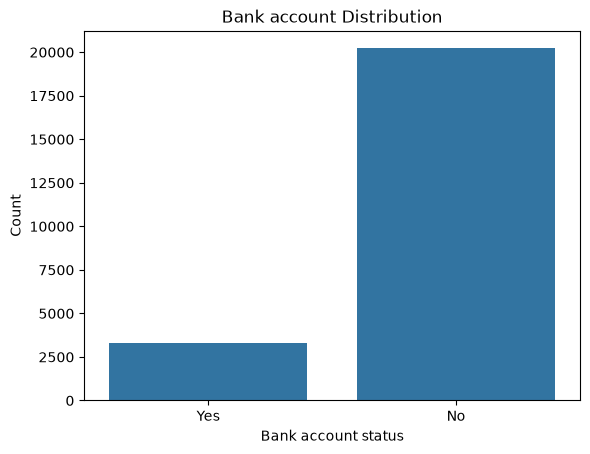

In [18]:
# Value counts
print(financial_df["bank_account"].value_counts())

# Check the distribution of your target variable.    
sns.countplot(data=financial_df, x="bank_account")
plt.title("Bank account Distribution")
plt.xlabel("Bank account status")
plt.ylabel("Count")
plt.show()

__STEP 4: Separate Features from the target__

In [20]:
X = financial_df.drop(columns=['bank_account'])
y = financial_df['bank_account']

__STEP 5: Split the data into train and test__

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

__STEP 6:Encode categorical columns and scale numerical columns__ 

In [23]:
# ENCODING
# Select the categorical colunmns for both test and train variables.    
X_train_cat_cols = X_train.select_dtypes(include=['str','object']).columns.tolist()
X_test_cat_cols = X_test.select_dtypes(include=['str','object']).columns.tolist()  

X_train_cat_cols.append('year')
X_test_cat_cols.append('year')

X_train_encoded = pd.get_dummies(X_train, columns=X_train_cat_cols, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=X_test_cat_cols, drop_first=True, dtype=int)


In [31]:
# SCALING
# Scale the numerical columns using the standard scaler
from sklearn.preprocessing import StandardScaler 

numerical_cols = X_train.select_dtypes(include=['int','float']).columns.tolist()
numerical_cols.remove("year")

# Instantiate the scaler
scaler = StandardScaler()

X_train_encoded[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_encoded[numerical_cols] = scaler.fit(X_test_encoded[numerical_cols])

In [35]:
X_train

,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
19929,Tanzania,2017,Urban,Yes,2,25,Female,Spouse,Single/Never Married,Primary education,Remittance Dependent
13449,Rwanda,2016,Rural,Yes,4,46,Female,Head of Household,Widowed,Secondary education,Farming and Fishing
5449,Kenya,2018,Urban,Yes,4,39,Male,Head of Household,Married/Living together,Secondary education,Self employed
6956,Rwanda,2016,Rural,Yes,5,61,Female,Head of Household,Widowed,No formal education,Farming and Fishing
2737,Kenya,2018,Rural,No,5,24,Female,Spouse,Married/Living together,Primary education,Farming and Fishing
...,...,...,...,...,...,...,...,...,...,...,...
11964,Rwanda,2016,Rural,Yes,4,27,Female,Spouse,Married/Living together,Primary education,Farming and Fishing
21575,Uganda,2018,Rural,Yes,9,40,Female,Spouse,Married/Living together,Primary education,Self employed
5390,Kenya,2018,Rural,Yes,4,35,Female,Head of Household,Widowed,Tertiary education,Formally employed Government
860,Kenya,2018,Urban,Yes,2,42,Male,Head of Household,Married/Living together,Tertiary education,Self employed


In [34]:
X_train_encoded.head()

,household_size,age_of_respondent,country_Rwanda,country_Tanzania,country_Uganda,location_type_Urban,cellphone_access_Yes,gender_of_respondent_Male,relationship_with_head_Head of Household,relationship_with_head_Other non-relatives,...,job_type_Formally employed Government,job_type_Formally employed Private,job_type_Government Dependent,job_type_Informally employed,job_type_No Income,job_type_Other Income,job_type_Remittance Dependent,job_type_Self employed,year_2017,year_2018
19929,-0.809509,-0.834855,0,1,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
13449,0.092526,0.439811,1,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5449,0.092526,0.014922,0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,1,0,1
6956,0.543544,1.350287,1,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2737,0.543544,-0.895554,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
